# AUD/USD Exchange Rate Analysis & Forecasting

## Overview & Workflow

This notebook analyzes the historical AUD/USD exchange rate data from 2020 to 2026, performs exploratory data analysis, conducts time series decomposition to identify trends and seasonality, and builds a SARIMA forecasting model to predict future exchange rates for the next 60 trading periods.

## 1. Install required packages

In [1]:
pip install yfinance pandas matplotlib numpy scikit-learn seaborn nbformat statsmodels

Note: you may need to restart the kernel to use updated packages.


## 2. Import the necessary libraries

In [2]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# This will make sure the graphs display in line without any issues
import plotly.offline as pyo
pyo.init_notebook_mode(connected = True)


In [3]:
# FX ticker for AUD/USD
currency_symbol = input("Currency Pair (e.g., AUDUSD):") + "=X" # "AUDUSD"

# Start and end date for historical download
start_date = input("Start(YYYY-MM-DD):") # "2020-01-01"
end_date = input("End(YYYY-MM-DD):") # "2026-06-28" - yesterday

In [4]:
# Download data from yfinance
df = yf.download(currency_symbol, start = start_date, end = end_date)

# convert the Date index into a column
df = df.reset_index()

# Flatten single-level column names
df.columns = df.columns.get_level_values(0)

# Save the downloaded data to CSV
df.to_csv("currency.csv")

# Show the first few rows
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2020-01-01,0.701700,0.704500,0.701508,0.701508,0
1,2020-01-02,0.701951,0.702100,0.698130,0.701892,0
2,2020-01-03,0.698519,0.698661,0.693140,0.698370,0
3,2020-01-06,0.694420,0.695900,0.692602,0.694729,0
4,2020-01-07,0.693731,0.694100,0.686111,0.693720,0


## 3. EDA (Exploratory Data Analysis)

In [5]:
# Display summary information about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    1688 non-null   datetime64[s]
 1   Close   1688 non-null   float64      
 2   High    1688 non-null   float64      
 3   Low     1688 non-null   float64      
 4   Open    1688 non-null   float64      
 5   Volume  1688 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 79.3 KB


In [6]:
# Check for missing values in each column
df.isnull().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
# Remove rows with missing values
df = df.dropna()

In [8]:
# Quick look at the data 
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,1688,1688.000000,1688.000000,1688.000000,1688.000000,1688.0
mean,2023-03-27 22:32:07,0.685950,0.689075,0.682846,0.686004,0.0
min,2020-01-01 00:00:00,0.574290,0.584020,0.552000,0.574640,0.0
25%,2021-08-12 18:00:00,0.653670,0.656100,0.651097,0.653673,0.0
50%,2023-03-27 12:00:00,0.674719,0.677950,0.671835,0.674748,0.0
75%,2024-11-06 06:00:00,0.716423,0.718907,0.713600,0.716527,0.0
max,2026-06-26 00:00:00,0.797703,0.820760,0.794849,0.797510,0.0
std,NaN,0.041818,0.041757,0.041836,0.041819,0.0


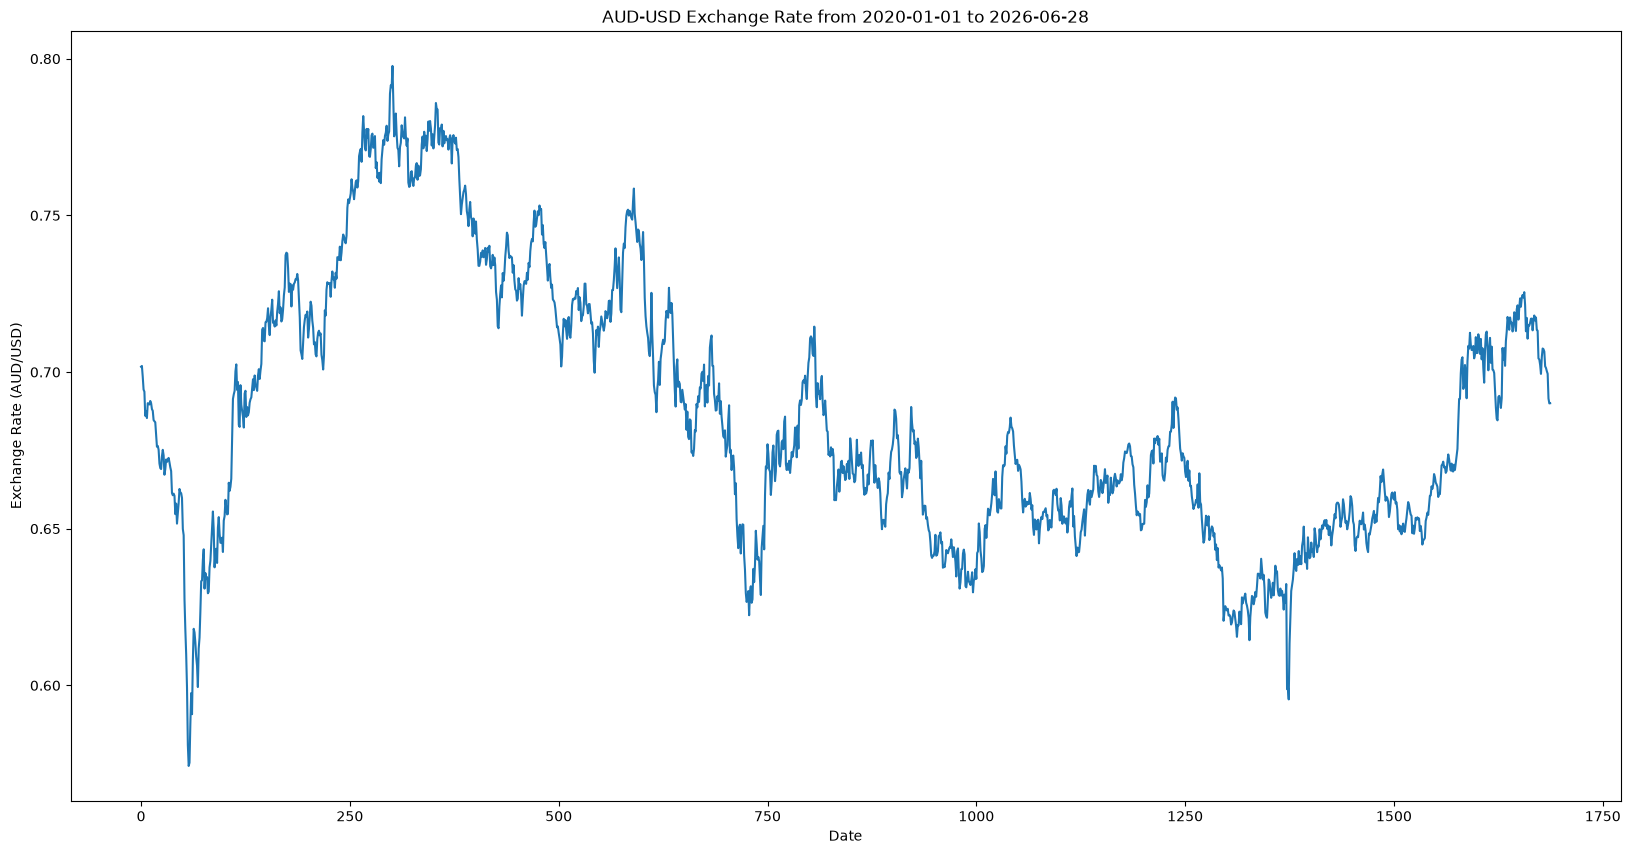

In [9]:
# Plot the AUD-USD closing price over time
fig, ax = plt.subplots(figsize = (20,10))
plt.title(f"AUD-USD Exchange Rate from {start_date} to {end_date}")
sns.lineplot(data = df, x = df.index, y = "Close")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (AUD/USD)")
plt.show()

In [10]:
# Adding year and month columns for better and deeper understanding
df["Date"] = pd.to_datetime(df["Date"], format = "%Y-%m-%d")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

print(df.head())

# Import Plotly modules for interactive visualizations
import plotly.graph_objs as go
import plotly.io as pio

# Average yearly growth

## Grouping by year, we are taking the aggregate of Close column
## Subtracting the last and first value of Close column and multipyling by 100 to get percentage
growth = df.groupby("Year").agg({"Close": lambda x: (x.iloc[-1] - x.iloc[0])/x.iloc[0]*100}) 

fig =  go.Figure()
fig.add_trace(go.Bar(x = growth.index,
                     y = growth["Close"],
                     name = "Yearly Growth"))

Price       Date     Close      High       Low      Open  Volume  Year  Month
0     2020-01-01  0.701700  0.704500  0.701508  0.701508       0  2020      1
1     2020-01-02  0.701951  0.702100  0.698130  0.701892       0  2020      1
2     2020-01-03  0.698519  0.698661  0.693140  0.698370       0  2020      1
3     2020-01-06  0.694420  0.695900  0.692602  0.694729       0  2020      1
4     2020-01-07  0.693731  0.694100  0.686111  0.693720       0  2020      1


## Time Series Analysis

<p><b>Note:</b> Time series analysis is carried out to understand if there is any trend or seasonality present hidden in our df.</p>

<Figure size 640x480 with 0 Axes>

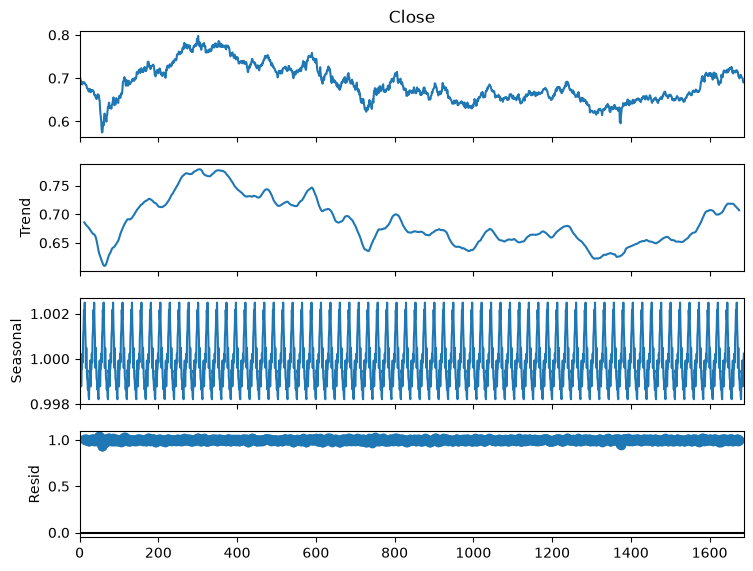

In [11]:
# This method is often used to understand trend/seasnality in our data
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["Close"], model = "multiplicative", period = 24)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(8,6)
fig.show()

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

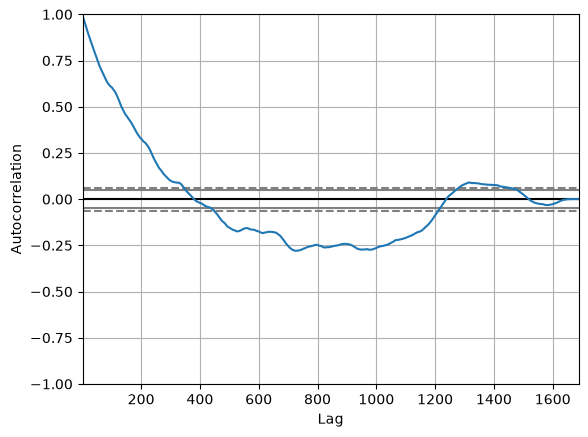

In [12]:
# To find P
pd.plotting.autocorrelation_plot(df["Close"])

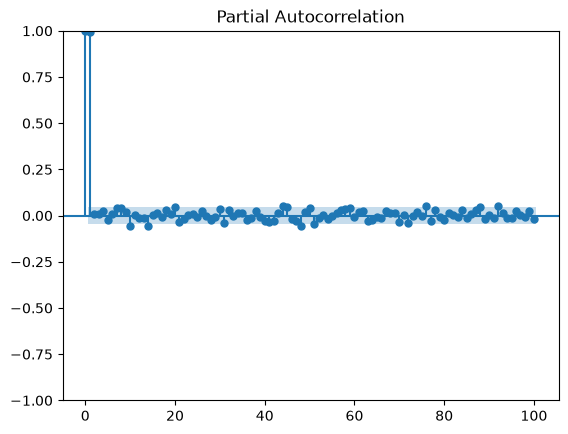

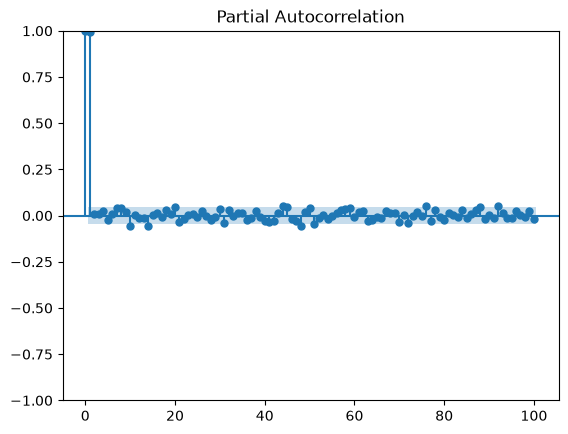

In [13]:
# To find q, plot partial autocorrelation 
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["Close"], lags = 100)

In [14]:
# Since its stationary data, d is 1 and hence 
p,d,q = 2,1,0

## SARIMA

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df["Close"], order = (p, d, q), seasonal_order = (p, d, q, 52))  
fitted = model.fit() 

print(fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 1688
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 52)   Log Likelihood                6272.932
Date:                            Mon, 29 Jun 2026   AIC                         -12535.865
Time:                                    21:04:11   BIC                         -12508.868
Sample:                                         0   HQIC                        -12525.851
                                           - 1688                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0108      0.022      0.489      0.625      -0.032       0.054
ar.L2         -0.0336      0.023   

## Predictions

In [16]:
# Generate SARIMA forecasts for the next 60 periods
predictions = fitted.predict(len(df), len(df) + 60)

print(predictions)

1688    0.692590
1689    0.693466
1690    0.690335
1691    0.689463
1692    0.692882
          ...   
1744    0.709939
1745    0.712358
1746    0.711348
1747    0.714385
1748    0.714837
Name: predicted_mean, Length: 61, dtype: float64


In [17]:
# Visualisation
fig = go.Figure()

fig.add_trace(go.Scatter(x = df.index, y = df["Close"], mode = "lines", name = "Training Data", line = dict(color = "magenta")))

# Adding predictions to the graph
fig.add_trace(go.Scatter(x = predictions.index, y = predictions,  mode = "lines", name = "Predictions", line = dict(color = "green")))

fig.update_layout(title = "Conversion Rate Predictions", xaxis_title = "Date", yaxis_title = "Close", legend_title = "Data", width = 900, height = 700)